In [ ]:
!pip install stable-baselines3==2.7.1
!pip install d3rlpy==2.8.1
!pip install gymnasium==1.2.3  # コンパチの都合でgymnasiumのバージョンを保つためにこの順番でインストールする

In [2]:
import collections
import d3rlpy
import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import stable_baselines3 as sb3
import torch


print("d3rlpy:", d3rlpy.__version__)
print("gymnasium:", gym.__version__)
print("matplotlib:", matplotlib.__version__)
print("numpy:", np.__version__)
print("stable baselines3:", sb3.__version__)
print("pytorch:", torch.__version__)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


d3rlpy: 2.8.1
gymnasium: 1.2.3
matplotlib: 3.10.0
numpy: 2.0.2
stable baselines3: 2.7.1
pytorch: 2.10.0+cpu


In [3]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    DEVICE_STRING = "cuda:0"
else:
    DEVICE_STRING = "cpu"

In [4]:
class MyInventoryEnv(gym.Env):
    def __init__(self, continuous_action_flag, initial_inventory, max_step, lead_time):
        super().__init__()
        # ステップ数をカウントするため
        self.current_step = 0
        # 行動が連続的かどうか(違う場合は離散的)のフラグ
        self.continuous_action_flag = continuous_action_flag
        # 1エピソードの最大ステップ数
        self.max_step = max_step
        # 発注から納品までのリードタイム
        self.lead_time = lead_time
        # 納品待ち数を保存するキュー # 初期値は[0, 0]とする
        self.delivery_queue = collections.deque(iterable=[0]*self.lead_time,
                                                maxlen=self.lead_time)
        # 行動(変数名はself.action_spaceがお作法)を定義
        if self.continuous_action_flag:  # 行動は連続値
            self.action_space = gym.spaces.Box(low=0,  # 発注量0～10を行動として、array形状を(1, )とする
                                               high=10,
                                               shape=(1, ),
                                               dtype=np.float32)
        else:  # 行動は離散値
            self.action_space = gym.spaces.Discrete(n=11,  # 発注量は0から11個の離散値で0～10の行動となる # array形状は( )でint扱いになる
                                                    seed=42,
                                                    start=0,
                                                    dtype=np.int32)
        # 状態(変数名はself.observation_spaceがお作法)を定義
        self.observation_space = gym.spaces.Box(low=0,  # 在庫数と納品待ち数(翌日と翌々日)として0～50の値で、array形状を(3, )とする
                                                high=50,
                                                shape=(1+self.lead_time, ),
                                                dtype=np.float32)
        # 状態の初期値を定義して、状態を定義する
        self.initial_state = np.array([initial_inventory]+list(self.delivery_queue),
                                      dtype=np.float32)
        self.state = self.initial_state.copy()  # 参照渡しを防ぐためにcopy()を使う # self.stateの編集がself.initial_stateに及ばないようにするため

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # 状態を初期状態にする
        self.state = self.initial_state.copy()  # 参照渡しを防ぐためにcopy()を使う # self.stateの編集がself.initial_stateに及ばないようにするため
        # キューを初期値にする
        self.delivery_queue = collections.deque(iterable=[0]*self.lead_time, maxlen=self.lead_time)
        # お作法としてinfo用の変数を作成する
        info = {}
        # ステップ数もリセットする
        self.current_step = 0
        # 初期状態とinfoを戻す
        return self.state, info

    def step(self, action):  # gymのお作法としてstep関数の引数はactionのみとする
        # ステップ数を+1する
        self.current_step = self.current_step + 1
        # 行動が連続値の時は整数部分を取得、離散値の時はそのまま
        if self.continuous_action_flag:
            preprocessed_action = np.round(a=action[0],  # 形状は(1, )なので[0]で要素を取得して四捨五入する
                                           decimals=0)
        else:
            preprocessed_action = int(action)  # そのまま(念のためint型にする)
        # 前々日に発注した数を納品する(キューの前から1つ取り出す)
        arrived_item = self.delivery_queue.popleft()
        # 需要は期待値が3のポアソン分布からサンプリングする
        demand = np.random.poisson(lam=3,
                                   size=(1, ))
        # サンプリングした需要と、納品数を踏まえて、在庫量を更新する
        inventory = np.clip(a=self.state[0] - demand[0] + arrived_item,
                            a_min=0,  # 在庫量はマイナスにはならない
                            a_max=50,  # 在庫量はself.observation_stateで定義したhigh=50を超えないようにするため
                            dtype=np.float32)
        # 行動(発注量)をキューの後ろに保存する
        self.delivery_queue.append(preprocessed_action)
        # 状態(在庫量と納品待ち数)を更新する
        self.state = np.array([inventory]+list(self.delivery_queue),
                              dtype=np.float32)
        # 在庫数15を基準として報酬を設定する # 在庫数15付近を保つように行動するようになると思う
        delta = abs(self.state[0] - 15)
        if 0 < delta < 5:
            reward = 1.0
        elif 5 <= delta < 10:
            reward = 0
        else:
            reward = - (delta * 0.1)
        # 発注を行う場合は発注コスト発生として報酬を減らす # ポアソン分布の期待値3の需要を見破られて発注を定期的に3にする事を防ぐ
        if preprocessed_action != 0:
            reward = reward - 0.5
        # 在庫量が0になった場合は在庫管理が適切でなかったとしてterminatedをtrueにする
        if self.state[0] == 0:
            terminated = True
        else:
            terminated = False
        # ステップ数が最大ステップ数になったらtruncatedをtrueにする
        if self.current_step == self.max_step:
            truncated = True
        else:
            truncated = False
        # お作法としてinfoを用意する
        info = {}
        # 状態、報酬、terminated、truncated、infoの並びで戻す
        return self.state, reward, terminated, truncated, info

In [5]:
def collect_data_by_trained_actor(algorithm_name, env, model, timestep):
    state_list = []
    action_list = []
    reward_list = []
    terminated_list = []
    truncated_list = []
    state, _ = env.reset()
    for i in range(timestep):
        predicted_action, hidden = model.predict(observation=state,
                                                 deterministic=True)
        next_state, reward, terminated, truncated, info = env.step(action=predicted_action)
        state_list.append(state)
        action_list.append(predicted_action)
        reward_list.append(reward)
        terminated_list.append(terminated)
        truncated_list.append(truncated)
        if terminated or truncated:
            state, _ = env.reset()
        else:
            state = next_state
    state_array = np.array(object=state_list,
                           dtype=np.float32)  # 形状は(timestep数, 3)
    action_array = np.array(object=action_list,
                            dtype=np.float32).reshape((-1, 1))  # 形状は(timestep数, 1)
    reward_array = np.array(object=reward_list,
                            dtype=np.float32)  # 形状は(timestep数, )
    terminated_array = np.array(object=terminated_list,
                                dtype=np.float32)  # 形状は(timestep数, )
    truncated_array = np.array(object=truncated_list,
                               dtype=np.float32)  # 形状は(timestep数, )
    return (state_array, action_array, reward_array, terminated_array, truncated_array)

In [6]:
def inference_timestep(algorithm_name, env, model, timestep):
    state, _ = env.reset()
    total_reward = 0
    inventory_list = []
    available_inventory_list = []
    for i in range(timestep):
        print("{a}:{b}ステップ: 在庫量:{c} 翌納品:{d} 翌々納品(action):{e}".format(a=algorithm_name, b=i, c=state[0], d=state[1], e=state[2]))
        inventory_list.append(state[0])
        available_inventory_list.append(state[0]+state[1]+state[2])
        if algorithm_name in ["CQL-SAC", "CQL-DDQN"]:
            state = state.reshape(1, -1)  # d3rlpyライブラリーのモデルは入力データにバッチ軸を求めるので、形状を(3, )から(1, 3)に変える
            # https://d3rlpy.readthedocs.io/en/latest/references/algos.html#d3rlpy.algos.QLearningAlgoBase.predict
            predicted_action = model.predict(x=state)  # 出力の形状は(1, 1) # (入力したstateの時系列数, actionの次元数)
            predicted_action = predicted_action[0]  # [0]で取得して(1, )にする # env.stepでは行動の形状は(1, )を想定しているため
        else:
            predicted_action, hidden = model.predict(observation=state,
                                                     deterministic=True)
        next_state, reward, terminated, truncated, info = env.step(action=predicted_action)
        total_reward = total_reward + reward
        if terminated or truncated:
            break
        state = next_state
    print("{a}:報酬合計:{b}".format(a=algorithm_name, b=total_reward))
    return inventory_list, available_inventory_list

In [ ]:
# 経験バッファにはPPOで推論した行動のデータを保存するために、まずは環境からのデータを使ってPPOを学習する
env_ppo = MyInventoryEnv(continuous_action_flag=False,  # PPOは離散的な行動を対象とする
                         initial_inventory=20,
                         max_step=31,
                         lead_time=2)
# https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html#stable_baselines3.ppo.PPO
model_ppo = sb3.PPO(policy="MlpPolicy",
                    env=env_ppo,
                    learning_rate=0.001,
                    n_steps=2048,  # バッファに保存するステップ数 # エピソード完了した際はそのまま次のエピソードが開始されて指定のステップ数まで保存される
                    batch_size=64,  # 学習時のミニバッチ数 # n_stepsで割り切れる値がテンソルの形状的にキレイ
                    n_epochs=10,  # バッファのデータを使って何回ActorとCriticを学習するか
                    gamma=0.98,  # TD法やモンテカルロ法で価値を算出する際の割引率
                    gae_lambda=0.95,  # Actorの目的関数に用いるアドバンテージ(A=Q-V)とみなすGAE(割引率とλを使ってTD法を積み重ねる)を算出する際のモンテカルロの割合(0ならばTD法、1ならばモンテカルロ法)
                    clip_range=0.2,  # Actorの損失値を求める際の新旧Actorの確率比率のクリッピング幅(0.2ならば0.8～1.2になる)
                    # verbose=1,  # 学習時にn_steps数毎に出力するログの詳細具合
                    device=DEVICE)
model_ppo.learn(total_timesteps=102400,  # 学習に用いるデータのステップ数 # n_steps数 × バッファを更新する回数
                progress_bar=True)

In [ ]:
datas_array = collect_data_by_trained_actor(algorithm_name="ppo",  # 学習したPPOによる推論の行動で経験バッファ用のデータを環境から収集する # 行動は離散的
                                            env=env_ppo,
                                            model=model_ppo,
                                            timestep=1000)  # 1000件のデータを収集する
dataset_cql_ddqn = d3rlpy.dataset.MDPDataset(observations=datas_array[0],
                                             actions=datas_array[1],
                                             rewards=datas_array[2],
                                             terminals=datas_array[3],
                                             timeouts=datas_array[4])

In [9]:
# https://d3rlpy.readthedocs.io/en/latest/references/algos.html#d3rlpy.algos.DiscreteCQLConfig
# DiscreteCQLは「Double DQN(DDQN)にCQLペナルティを盛り込んだもの」
# DDQNは状態を入力して、行動の次元数の分のQ値(行動価値)を出力する形で、価値ベースなので推論では最大Q値の行動を選択する
# 学習では経験バッファ(正解データ)の行動を正解として、その行動でのQ値からのTD誤差を使って目的関数の値を算出して、逆符号で損失値にして誤差逆伝播する
# DiscreteCQLの目的関数は「DDQNでのTD誤差」に「(状態を入力して得られる全ての行動のQ値をlog-sum-expで期待値 － 経験バッファの行動でのQ値) × 重みα」を加算したもので、
# CQLペナルティは「(状態を入力して得られる全ての行動のQ値をlog-sum-expで期待値 － 経験バッファの行動でのQ値)」になる
model_config_cql_ddqn = d3rlpy.algos.DiscreteCQLConfig(batch_size=32,
                                                       gamma=0.99,  # DDQNの損失値を求める際のTD誤差での割引率
                                                       learning_rate=0.0003,  # DDQNのQ Networkの学習率
                                                       n_critics=2,  # DDQNのQ NetworkとTarget Q Networkのペアの個数(2ならばQ Networkが2つ、Target Q Networkが2つの合計4つ)
                                                       target_update_interval=100,  # Q NetworkのパラメータをTarget Q Networkに同期する間隔ステップ数
                                                       alpha=1.0)  # CQLペナルティに掛ける重み
model_cql_ddqn = model_config_cql_ddqn.create(device=DEVICE_STRING)

In [10]:
# DiscreteCQL(DDQN+CQL)を学習する
model_cql_ddqn.fit(dataset=dataset_cql_ddqn,
                   n_steps=5000,
                   n_steps_per_epoch=1000,
                   with_timestamp=True,
                   show_progress=True)

2026-04-03 05:48.14 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float32')], shape=[(3,)]), action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_space=<ActionSpace.DISCRETE: 2>, action_size=10)
2026-04-03 05:48.14 [debug    ] Building models...            
2026-04-03 05:48.14 [debug    ] Models have been built.       
2026-04-03 05:48.14 [info     ] Directory is created at d3rlpy_logs/DiscreteCQL_20260403054814
2026-04-03 05:48.14 [info     ] Parameters                     params={'observation_shape': [3], 'action_size': 10, 'config': {'type': 'discrete_cql', 'params': {'batch_size': 32, 'gamma': 0.99, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'none', 'params': {}}, 'reward_scaler': {'type': 'none', 'params': {}}, 'compile_graph': False, 'learning_rate': 0.0003, 'optim_factory': {'type': 'ada

Epoch 1/5:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-03 05:48.24 [info     ] DiscreteCQL_20260403054814: epoch=1 step=1000 epoch=1 metrics={'time_sample_batch': 0.0007573707103729248, 'time_algorithm_update': 0.00908176064491272, 'loss': 0.8715453978180885, 'td_loss': 0.3887604159116745, 'conservative_loss': 0.48278498120605945, 'time_step': 0.009947188377380371} step=1000
2026-04-03 05:48.25 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteCQL_20260403054814/model_1000.d3


Epoch 2/5:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-03 05:48.35 [info     ] DiscreteCQL_20260403054814: epoch=2 step=2000 epoch=2 metrics={'time_sample_batch': 0.0007523829936981201, 'time_algorithm_update': 0.009476140022277832, 'loss': 0.9438120267391205, 'td_loss': 0.5738593994230032, 'conservative_loss': 0.3699526278376579, 'time_step': 0.010336803674697876} step=2000
2026-04-03 05:48.35 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteCQL_20260403054814/model_2000.d3


...

Epoch 4/5:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-03 05:48.55 [info     ] DiscreteCQL_20260403054814: epoch=4 step=4000 epoch=4 metrics={'time_sample_batch': 0.0007382409572601319, 'time_algorithm_update': 0.009458105564117431, 'loss': 1.3189860824346542, 'td_loss': 0.9923145335912704, 'conservative_loss': 0.32667154774069784, 'time_step': 0.010296212673187257} step=4000
2026-04-03 05:48.55 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteCQL_20260403054814/model_4000.d3


Epoch 5/5:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-03 05:49.06 [info     ] DiscreteCQL_20260403054814: epoch=5 step=5000 epoch=5 metrics={'time_sample_batch': 0.0007581553459167481, 'time_algorithm_update': 0.009546799421310424, 'loss': 1.321369963645935, 'td_loss': 1.043530935704708, 'conservative_loss': 0.27783902585506437, 'time_step': 0.010403371334075928} step=5000
2026-04-03 05:49.06 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteCQL_20260403054814/model_5000.d3


[(1,
  {'time_sample_batch': 0.0007573707103729248,
   'time_algorithm_update': 0.00908176064491272,
   'loss': 0.8715453978180885,
   'td_loss': 0.3887604159116745,
   'conservative_loss': 0.48278498120605945,
   'time_step': 0.009947188377380371}),
 (2,
  {'time_sample_batch': 0.0007523829936981201,
   'time_algorithm_update': 0.009476140022277832,
   'loss': 0.9438120267391205,
   'td_loss': 0.5738593994230032,
   'conservative_loss': 0.3699526278376579,
   'time_step': 0.010336803674697876}),
 (3,
  {'time_sample_batch': 0.0006859536170959473,
   'time_algorithm_update': 0.008897277593612671,
   'loss': 1.1309931277036667,
   'td_loss': 0.7934140170812607,
   'conservative_loss': 0.33757911233603954,
   'time_step': 0.009678824424743653}),
 (4,
  {'time_sample_batch': 0.0007382409572601319,
   'time_algorithm_update': 0.009458105564117431,
   'loss': 1.3189860824346542,
   'td_loss': 0.9923145335912704,
   'conservative_loss': 0.32667154774069784,
   'time_step': 0.0102962126731872

CQL-DDQN:0ステップ: 在庫量:20.0 翌納品:0.0 翌々納品(action):0.0
CQL-DDQN:1ステップ: 在庫量:17.0 翌納品:0.0 翌々納品(action):8.0
CQL-DDQN:2ステップ: 在庫量:15.0 翌納品:8.0 翌々納品(action):0.0
CQL-DDQN:3ステップ: 在庫量:17.0 翌納品:0.0 翌々納品(action):0.0
CQL-DDQN:4ステップ: 在庫量:14.0 翌納品:0.0 翌々納品(action):8.0
CQL-DDQN:5ステップ: 在庫量:7.0 翌納品:8.0 翌々納品(action):0.0
CQL-DDQN:6ステップ: 在庫量:14.0 翌納品:0.0 翌々納品(action):8.0
CQL-DDQN:7ステップ: 在庫量:10.0 翌納品:8.0 翌々納品(action):0.0
CQL-DDQN:8ステップ: 在庫量:17.0 翌納品:0.0 翌々納品(action):8.0
CQL-DDQN:9ステップ: 在庫量:17.0 翌納品:8.0 翌々納品(action):0.0
CQL-DDQN:10ステップ: 在庫量:21.0 翌納品:0.0 翌々納品(action):0.0
CQL-DDQN:11ステップ: 在庫量:17.0 翌納品:0.0 翌々納品(action):8.0
CQL-DDQN:12ステップ: 在庫量:14.0 翌納品:8.0 翌々納品(action):0.0
CQL-DDQN:13ステップ: 在庫量:20.0 翌納品:0.0 翌々納品(action):0.0
CQL-DDQN:14ステップ: 在庫量:16.0 翌納品:0.0 翌々納品(action):8.0
CQL-DDQN:15ステップ: 在庫量:11.0 翌納品:8.0 翌々納品(action):0.0
CQL-DDQN:16ステップ: 在庫量:15.0 翌納品:0.0 翌々納品(action):8.0
CQL-DDQN:17ステップ: 在庫量:12.0 翌納品:8.0 翌々納品(action):0.0
CQL-DDQN:18ステップ: 在庫量:19.0 翌納品:0.0 翌々納品(action):0.0
CQL-DDQN:19ステップ: 在庫量:16.0 翌納品:0.0 翌々納品(act

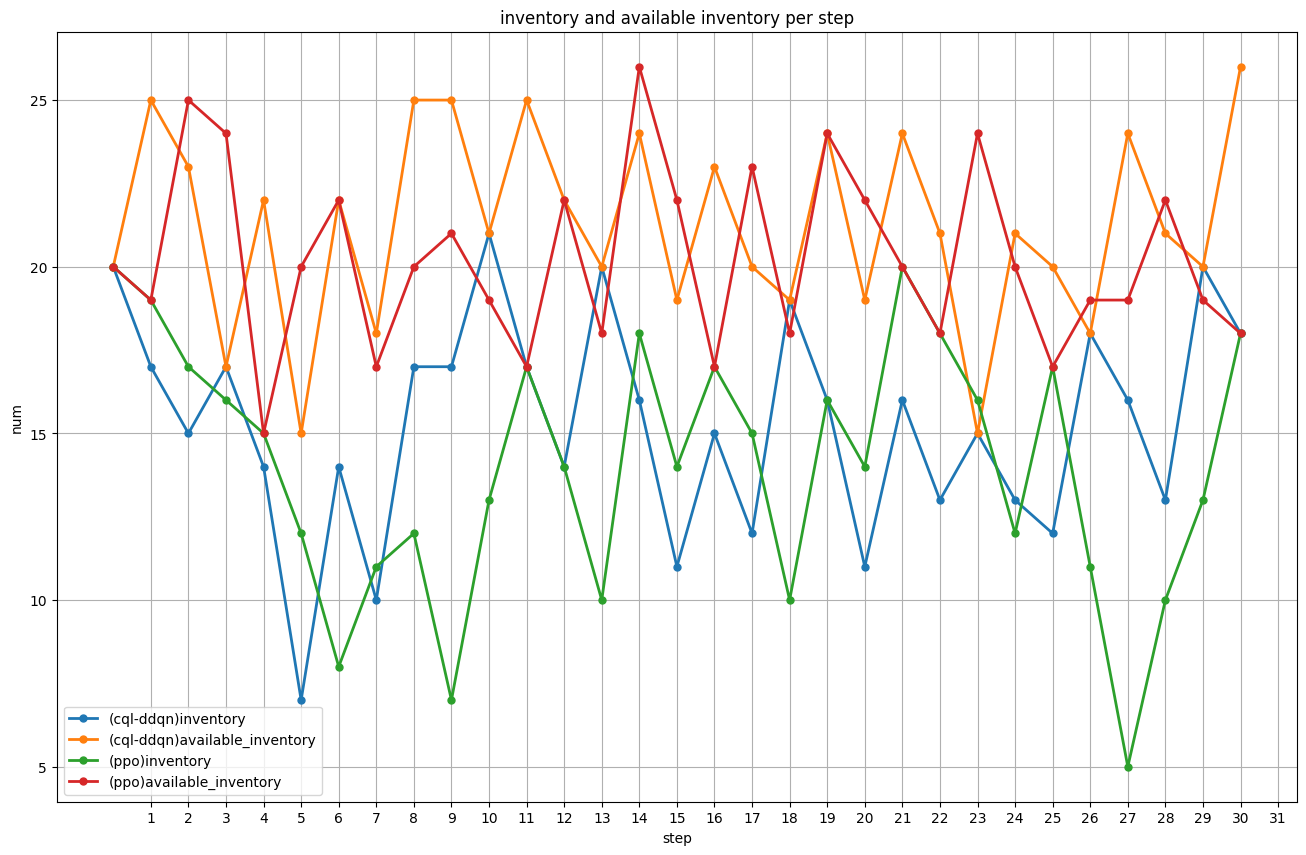

In [11]:
env_cql_ddqn = MyInventoryEnv(continuous_action_flag=False,  # DiscreteCQL(DDQN+CQL)は離散的な行動を対象とする
                              initial_inventory=20,
                              max_step=31,
                              lead_time=2)
inventory_list_cql_ddqn, available_inventory_list_cql_ddqn = inference_timestep(algorithm_name="CQL-DDQN",
                                                                                env=env_cql_ddqn,
                                                                                model=model_cql_ddqn,
                                                                                timestep=31)
inventory_list_ppo, available_inventory_list_ppo = inference_timestep(algorithm_name="PPO",
                                                                      env=env_ppo,
                                                                      model=model_ppo,
                                                                      timestep=31)
fig, (ax1) = plt.subplots(nrows=1, ncols=1, figsize=(16, 10))
ax1.plot(np.arange(stop=len(inventory_list_cql_ddqn)),
         inventory_list_cql_ddqn,
         label="(cql-ddqn)inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(np.arange(stop=len(available_inventory_list_cql_ddqn)),
         available_inventory_list_cql_ddqn,
         label="(cql-ddqn)available_inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(np.arange(stop=len(inventory_list_ppo)),
         inventory_list_ppo,
         label="(ppo)inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(np.arange(stop=len(available_inventory_list_ppo)),
         available_inventory_list_ppo,
         label="(ppo)available_inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.legend(loc=0)
ax1.set_title(label="inventory and available inventory per step")
ax1.set_xlabel(xlabel="step")
ax1.set_ylabel(ylabel="num")
ax1.set_xticks(ticks=np.arange(stop=len(inventory_list_ppo))+1)
ax1.grid(True)
plt.show()